# Data Cleaning — Traffic Collision Dataset

This notebook prepares the raw Ottawa traffic collision dataset for machine learning. The goal is to produce a clean, well-structured dataset suitable for binary classification of accident severity (fatal vs. non-fatal).

**Pipeline overview:**

| Step | Description |
|---|---|
| 1. Initial Exploration | Understand the dataset shape, types, and distributions |
| 2. Duplicate Detection | Confirm there are no duplicate records |
| 3. Missing Value Handling | Identify, drop, and impute missing values appropriately |
| 4. Data Type Standardization | Correct column types for downstream processing |
| 5. Feature Reduction | Remove redundant, identifier, and leakage-prone columns |
| 6. Label Normalization | Strip numeric prefixes from categorical values |
| 7. Target Construction | Collapse 4-class target into binary fatal/non-fatal |

**Input:** `Traffic_Collision_Data.csv` — 94,406 records, 28 features  
**Output:** `cleaned_data.csv` — 91,843 records, 11 features

## Imports

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 100)  

import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
# Load the raw traffic collision dataset
df = pd.read_csv('Traffic_Collision_Data.csv')

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.sample(3)

Dataset shape: 94,406 rows x 28 columns


,X,Y,X_Coordinate,Y_Coordinate,ID,Geo_ID,Accident_Year,Accident_Date,Location,Classification_Of_Accident,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,Max_injury,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
26308,-8.409815e+06,5.690873e+06,379384.6181,5033652.819,2018--26792,__3Z08T0,2018,12/21/2018,INNES RD btwn KEYSTONE CRT & CLEROUX CRES (__3...,03 - P.D. only,02 - Angle,02 - Wet,02 - Rain,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.438829,-75.546656,26309
28275,-8.410212e+06,5.680175e+06,379194.1439,5026151.967,2018--28093,__3Z07FX,2018,6/19/2018,HIGHWAY 417 btwn HWY417 IC109 RAMP63 & HWY417 ...,03 - P.D. only,03 - Rear end,01 - Dry,01 - Clear,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.371361,-75.550222,28276
8880,-8.409192e+06,5.695992e+06,379780.1507,5037242.936,2017--8889,__3Z08PC,2017,10/5/2017,REGIONAL ROAD 174 WB btwn OR174 IC105 RAMP63 &...,02 - Non-fatal injury,03 - Rear end,01 - Dry,01 - Clear,01 - Daylight,10 - No control,2.0,NaN,NaN,NaN,Minor,1.0,NaN,1.0,NaN,NaN,45.471087,-75.541054,8881


In [3]:
# Inspect column data types and count of non-null values per column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94406 entries, 0 to 94405
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   X                           94406 non-null  float64
 1   Y                           94406 non-null  float64
 2   X_Coordinate                94406 non-null  float64
 3   Y_Coordinate                94406 non-null  float64
 4   ID                          94406 non-null  object 
 5   Geo_ID                      92330 non-null  object 
 6   Accident_Year               94406 non-null  int64  
 7   Accident_Date               94406 non-null  object 
 8   Location                    92330 non-null  object 
 9   Classification_Of_Accident  94406 non-null  object 
 10  Initial_Impact_Type         94394 non-null  object 
 11  Road_1_Surface_Condition    94405 non-null  object 
 12  Environment_Condition_1     94393 non-null  object 
 13  Light                       943

In [4]:
# Confirm total number of records and features
print(f"Records : {df.shape[0]:,}")
print(f"Features: {df.shape[1]}")

Records : 94,406
Features: 28


In [5]:
# Summary statistics for all columns (numeric and categorical)
df.describe(include='all')

,X,Y,X_Coordinate,Y_Coordinate,ID,Geo_ID,Accident_Year,Accident_Date,Location,Classification_Of_Accident,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,Max_injury,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal,Lat,Long,ObjectId
count,9.440600e+04,9.440600e+04,94406.000000,9.440600e+04,94406,92330,94406.000000,94406,92330,94406,94394,94405,94393,94392,94376,94238.000000,1831.000000,1665.00000,791.000000,15165,15223.000000,6590.000000,8656.000000,817.000000,169.000000,94406.000000,94406.000000,94406.000000
unique,NaN,NaN,NaN,NaN,94406,14900,NaN,2557,14900,4,8,11,9,6,14,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,2017--101,__3Z07AN,NaN,2/18/2022,HIGHWAY 417 btwn HWY417 IC124 RAMP65 & HWY417 ...,03 - P.D. only,03 - Rear end,01 - Dry,01 - Clear,01 - Daylight,10 - No control,NaN,NaN,NaN,NaN,Minor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,1,521,NaN,166,521,76671,31720,64171,74472,63755,43700,NaN,NaN,NaN,NaN,8450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,-8.427894e+06,5.675457e+06,366681.116243,5.021918e+06,NaN,NaN,2020.132439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.866349,1.038777,1.00961,1.015171,NaN,1.293438,1.208194,1.219616,1.112607,1.065089,45.334280,-75.709057,47203.500000
std,1.753820e+04,1.571708e+05,13998.163610,1.389519e+05,NaN,NaN,2.367294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.564350,0.204120,0.10921,0.132254,NaN,0.719960,0.554833,0.576199,0.583305,0.270406,1.254323,0.157548,27252.809094
min,-8.820655e+06,0.000000e+00,0.000000,0.000000e+00,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.00000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-79.237290,1.000000
25%,-8.432998e+06,5.674030e+06,363180.599300,5.021664e+06,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,1.00000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,45.332566,-75.754909,23602.250000
50%,-8.426562e+06,5.681332e+06,367649.068150,5.026852e+06,NaN,NaN,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,1.00000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,45.378657,-75.697095,47203.500000
75%,-8.420494e+06,5.687625e+06,371921.717000,5.031271e+06,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,1.00000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,45.418357,-75.642588,70804.750000


---
## Step 2 — Duplicate Detection

We check whether any rows are exact duplicates across all columns. Duplicate records would bias model training by artificially inflating the frequency of certain patterns.

In [6]:
# Count exact duplicate rows
df.duplicated().sum()

0

---
## Step 3 — Missing Value Handling

From `df.info()` and `df.describe()`, two distinct patterns of missing data were identified, each requiring a different treatment strategy.

### 3a — Identify Columns with Missing Values

The following columns have significantly fewer non-null records than the total 94,406 rows, indicating missing data:

- **Participant count fields** (`num_of_pedestrians`, `num_of_bicycles`, `num_of_motorcycles`): sparse because they are only populated when those user types are involved in the collision
- **Injury detail fields** (`Max_injury`, `num_of_injuries`, `num_of_minimal`, `num_of_minor`, `num_of_major`, `num_of_fatal`): populated only for injury-related collisions

We inspect a sample to understand the missingness pattern.

In [7]:
# Inspect a sample of the columns with the most missing values
df[['num_of_pedestrians', 'num_of_bicycles', 'num_of_motorcycles',
    'Max_injury', 'num_of_injuries', 'num_of_minimal',
    'num_of_minor', 'num_of_major', 'num_of_fatal']].sample(5, random_state=42)

,num_of_pedestrians,num_of_bicycles,num_of_motorcycles,Max_injury,num_of_injuries,num_of_minimal,num_of_minor,num_of_major,num_of_fatal
63634,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10656,1.0,NaN,NaN,Minimal,1.0,1.0,NaN,NaN,NaN
77937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3b — Drop Data Leakage Columns

The injury detail fields (`Max_injury`, `num_of_injuries`, `num_of_minimal`, `num_of_minor`, `num_of_major`, `num_of_fatal`) are **post-incident** measurements. They are recorded *after* the accident severity has already been determined. Including them would cause **data leakage**, allowing the model to see information derived from the target variable, which would produce artificially inflated performance metrics that would not hold in production.

These six columns are dropped entirely.

In [8]:
# Drop post-incident injury fields that are derived from the target variable (data leakage)
leakage_cols = ['Max_injury', 'num_of_injuries', 'num_of_minimal',
                'num_of_minor', 'num_of_major', 'num_of_fatal']

df.drop(leakage_cols, axis=1, inplace=True)
print(f"Remaining features after leakage removal: {df.shape[1]}")

Remaining features after leakage removal: 22


### 3c — Impute Participant Count Fields with Zero

For `num_of_pedestrians`, `num_of_bicycles`, `num_of_motorcycles`, and `num_of_vehicles`, missing values mean those road user types were **not involved** in the collision, not that the data is unknown. Replacing NaN with `0` is correct here.

In [9]:
# Fill NaN with 0 — absence of a value means that road user type was not involved
df['num_of_pedestrians'] = df['num_of_pedestrians'].fillna(0)
df['num_of_bicycles']    = df['num_of_bicycles'].fillna(0)
df['num_of_motorcycles'] = df['num_of_motorcycles'].fillna(0)
df['num_of_vehicles']    = df['num_of_vehicles'].fillna(0)

# Confirm no missing values remain in these columns
print("Remaining nulls in participant count columns:")
print(df[['num_of_vehicles','num_of_pedestrians','num_of_bicycles','num_of_motorcycles']].isnull().sum())

Remaining nulls in participant count columns:
num_of_vehicles       0
num_of_pedestrians    0
num_of_bicycles       0
num_of_motorcycles    0
dtype: int64


---
## Step 4 — Data Type Standardization

After imputation, participant count columns are stored as `float64` due to the NaN fill operation. We cast them to `int` to reflect their discrete count nature. We also parse `Accident_Date` from a string into a proper `datetime` type to enable date-based operations later.

In [10]:
# Cast participant count columns from float to int (they represent whole-number counts)
df['num_of_motorcycles'] = df['num_of_motorcycles'].astype(int)
df['num_of_bicycles']    = df['num_of_bicycles'].astype(int)
df['num_of_pedestrians'] = df['num_of_pedestrians'].astype(int)
df['num_of_vehicles']    = df['num_of_vehicles'].astype(int)

# Parse the date string into a proper datetime type (format: MM/DD/YYYY)
df['Accident_Date'] = pd.to_datetime(df['Accident_Date'], format='%m/%d/%Y')

# Confirm updated types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94406 entries, 0 to 94405
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   X                           94406 non-null  float64       
 1   Y                           94406 non-null  float64       
 2   X_Coordinate                94406 non-null  float64       
 3   Y_Coordinate                94406 non-null  float64       
 4   ID                          94406 non-null  object        
 5   Geo_ID                      92330 non-null  object        
 6   Accident_Year               94406 non-null  int64         
 7   Accident_Date               94406 non-null  datetime64[ns]
 8   Location                    92330 non-null  object        
 9   Classification_Of_Accident  94406 non-null  object        
 10  Initial_Impact_Type         94394 non-null  object        
 11  Road_1_Surface_Condition    94405 non-null  object    

---
## Step 5 — Feature Reduction

The following columns carry no predictive signal and are dropped:

| Column(s) | Reason for removal |
|---|---|
| `X`, `Y`, `X_Coordinate`, `Y_Coordinate` | Projected coordinate duplicates of `Lat`/`Long` |
| `ID`, `ObjectId` | Row identifiers — unique per record, no signal |
| `Geo_ID`, `Location` | High-cardinality strings; spatial info retained in `geo_df` |
| `Accident_Year` | Redundant — year is derivable from `Accident_Date` |
| `Lat`, `Long` | Retained in `geo_df` reference table; excluded from model |

In [11]:
# Drop columns that are redundant, identifier-only, or carry no predictive value
cols_to_drop = ['X', 'Y', 'X_Coordinate', 'Y_Coordinate',
                'ID', 'Location', 'Accident_Year',
                'Geo_ID', 'Lat', 'Long', 'ObjectId']

df.drop(cols_to_drop, axis=1, inplace=True)
print(f"Features remaining after reduction: {df.shape[1]}")

Features remaining after reduction: 11


In [12]:
# Move the target variable to the first column for readability
# Convention: target first, features after
target_variable = df.pop('Classification_Of_Accident')
df.insert(0, 'Classification_Of_Accident', target_variable)

df.head()

,Classification_Of_Accident,Accident_Date,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles
0,02 - Non-fatal injury,2017-01-04,02 - Angle,03 - Loose snow,03 - Snow,01 - Daylight,10 - No control,2,0,0,0
1,03 - P.D. only,2017-01-05,05 - Turning movement,02 - Wet,01 - Clear,07 - Dark,01 - Traffic signal,2,0,0,0
2,02 - Non-fatal injury,2017-01-23,07 - SMV other,01 - Dry,01 - Clear,07 - Dark,01 - Traffic signal,1,1,0,0
3,03 - P.D. only,2017-01-04,01 - Approaching,06 - Ice,03 - Snow,05 - Dusk,11 - Roundabout,2,0,0,0
4,03 - P.D. only,2017-01-04,04 - Sideswipe,03 - Loose snow,03 - Snow,01 - Daylight,10 - No control,2,0,0,0


---
## Step 6 — Label Normalization

Categorical columns store values with leading numeric codes (e.g., `"02 - Angle"`, `"01 - Dry"`). These prefixes are artefacts of the source data encoding and carry no meaningful information. We strip them, keeping only the descriptive label (e.g., `"Angle"`, `"Dry"`), so encoding methods treat each category by its name rather than its prefix.

In [13]:
categorical_cols = [
    'Initial_Impact_Type',
    'Road_1_Surface_Condition',
    'Environment_Condition_1',
    'Light',
    'Traffic_Control'
]

# Split on ' - ' and keep only the text portion after the numeric prefix
for col in categorical_cols:
    df[col] = df[col].str.split('-').str.get(1).str.strip()

In [14]:
df.sample(2)

,Classification_Of_Accident,Accident_Date,Initial_Impact_Type,Road_1_Surface_Condition,Environment_Condition_1,Light,Traffic_Control,num_of_vehicles,num_of_pedestrians,num_of_bicycles,num_of_motorcycles
66629,03 - P.D. only,2022-02-12,Rear end,Ice,Freezing Rain,Daylight,Traffic signal,2,0,0,0
35782,03 - P.D. only,2019-06-15,Angle,Wet,Rain,Daylight,No control,2,0,0,0


---
## Step 7 — Target Variable Construction

The original target column `Classification_Of_Accident` contains four classes. We need to reduce this to a binary classification problem:

| Original Class | Count | Action |
|---|---|---|
| `01 - Fatal injury` | 170 | Kept as the **positive (fatal)** class |
| `02 - Non-fatal injury` | 15,002 | Merged into the **negative (non-fatal)** class |
| `03 - P.D. only` | 76,671 | Merged into the **negative (non-fatal)** class |
| `04 - Non-reportable` | 2,563 | **Dropped** — ambiguous, does not map to a clear severity outcome |

Property Damage Only (PD Only) collisions share the key characteristic of *no loss of life* with Non-fatal injury records, making them appropriate to merge into a single negative class.

In [15]:
# Inspect the current class distribution before collapsing
print("Original class distribution:")
print(df['Classification_Of_Accident'].value_counts())
print()
print("Class proportions:")
print(df['Classification_Of_Accident'].value_counts(normalize=True).round(4))

Original class distribution:
Classification_Of_Accident
03 - P.D. only           76671
02 - Non-fatal injury    15002
04 - Non-reportable       2563
01 - Fatal injury          170
Name: count, dtype: int64

Class proportions:
Classification_Of_Accident
03 - P.D. only           0.8121
02 - Non-fatal injury    0.1589
04 - Non-reportable      0.0271
01 - Fatal injury        0.0018
Name: proportion, dtype: float64


We now construct the binary target by:
1. Replacing `"03 - P.D. only"` with `"02 - Non-fatal injury"` to merge them into a single non-fatal class
2. Dropping all `"04 - Non-reportable"` records

Final binary class distribution:
Classification_Of_Accident
02 - Non-fatal injury    91673
01 - Fatal injury          170
Name: count, dtype: int64

Total records after filtering: 91,843


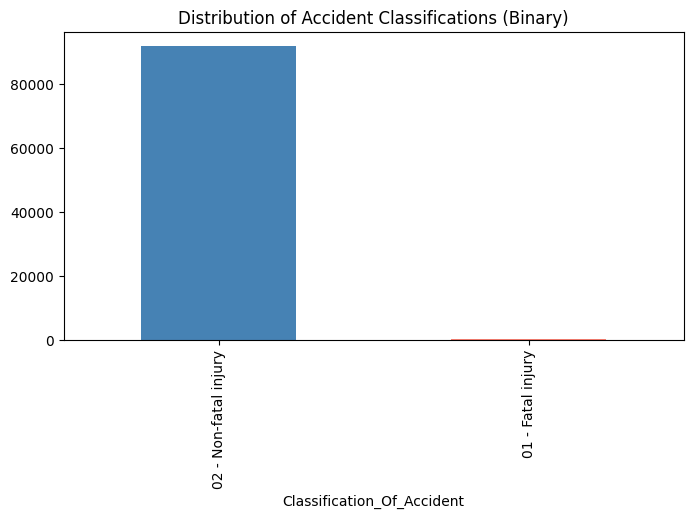

In [18]:
combined_df = df.copy()

# Step 1: Merge "P.D. only" into the non-fatal class
combined_df['Classification_Of_Accident'] = combined_df['Classification_Of_Accident'].replace(
    '03 - P.D. only', '02 - Non-fatal injury'
)

# Step 2: Remove "Non-reportable" records — outcome does not map to either class
combined_df.drop(
    combined_df[combined_df['Classification_Of_Accident'] == '04 - Non-reportable'].index,
    inplace=True
)

print("Final binary class distribution:")
print(combined_df['Classification_Of_Accident'].value_counts())
print(f"\nTotal records after filtering: {combined_df.shape[0]:,}")

# Visualise the class imbalance
combined_df['Classification_Of_Accident'].value_counts().plot(
    kind='bar', figsize=(8, 4), color=['steelblue', 'salmon']
)
plt.title('Distribution of Accident Classifications (Binary)')
plt.show()

In [17]:
# Export the cleaned dataset for use in the feature engineering pipeline
combined_df.to_csv('cleaned_data.csv', index=False)

print(f"Exported: cleaned_data.csv  ({combined_df.shape[0]:,} records x {combined_df.shape[1]} features)")

Exported: cleaned_data.csv  (91,843 records x 11 features)
